<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assigment_No_10(Customers_Churn_Prediction_Using_ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Data Understanding & Preparation**

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

### **Loading the Dataset**

In [3]:
df = pd.read_csv("/content/drive/MyDrive/All CSV Files/Telco-Customer-Churn.csv")

### **Exploring the Dataset**

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.shape

(7043, 21)

## **Checking Missing Values and Datatypes**

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### **Summarizing of descripted Statistic and Visualizing the distribution**

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


### **Churn Distribution**

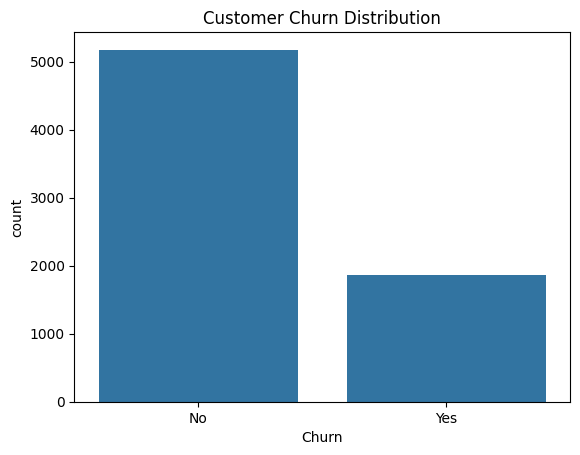

In [14]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

`Contract vs Churn`

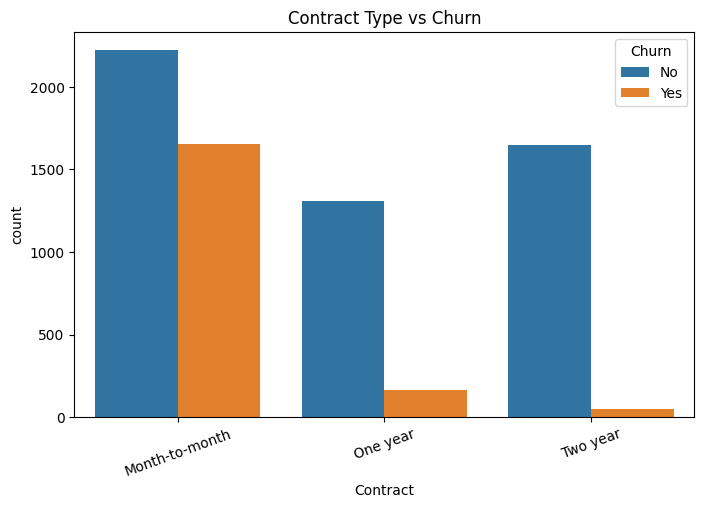

In [15]:
plt.figure(figsize=(8,5))
sns.countplot( data= df, x="Contract",hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

`Monthly Charges vs Churn`

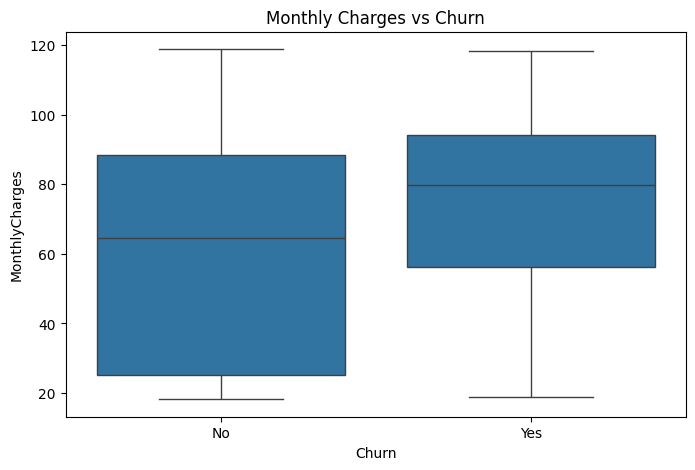

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn",y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

### **Cleaning and Processing Data**

### **Remove Unnessary Columns and Rows**

In [17]:
df = df.drop('customerID', axis = 1) # Customer ID no doesn't effects on Churn

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.duplicated().sum()

np.int64(22)

In [19]:
df[df.duplicated()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [20]:
df = df.drop_duplicates(keep='first')

In [21]:
df.shape

(7021, 20)

In [22]:
df.duplicated().sum()


np.int64(0)

### **Handling Missing Valuesa**

In [31]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

###**Endcoding Categorical Data**

In [32]:
df["Churn"] = df["Churn"].map({ "Yes": 1, "No": 0})

In [33]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [34]:
df = pd.get_dummies(df, drop_first=True)

In [35]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### **Spliting the dataset into training and testing**

In [36]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [55]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=69, stratify=y)

### **Scaling Numerical Features**

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**Model Implementation**

### **A.Logistic Regression**

### `Explanation:`

### `Trainig the Model`

In [54]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=69)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]



### `Evaluation:`

In [50]:
print("Logistic Regression Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Performance:
Accuracy:  0.8028
Precision: 0.6599
Recall:    0.5269
F1 Score:  0.5859
ROC-AUC:   0.8403


### **B.K-Nearest Neibours**

### `Trainig And Evaluating the Model`

In [52]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 9]

print("KNN Performance for Different K Values:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)
    y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    auc = roc_auc_score(y_test, y_prob_knn)

    print(f"K={k} -> Accuracy: {acc:.4f} | F1 Score: {f1:.4f} | ROC-AUC: {auc:.4f}")

KNN Performance for Different K Values:
K=3 -> Accuracy: 0.7381 | F1 Score: 0.4860 | ROC-AUC: 0.7324
K=5 -> Accuracy: 0.7523 | F1 Score: 0.5000 | ROC-AUC: 0.7633
K=7 -> Accuracy: 0.7708 | F1 Score: 0.5360 | ROC-AUC: 0.7903
K=9 -> Accuracy: 0.7744 | F1 Score: 0.5439 | ROC-AUC: 0.7986


### **C.Decision Tree**

### `Trainig the Model`





In [56]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=69)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]


### `Evaluation:`

In [57]:
print("Decision Tree Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

Decision Tree Performance
Accuracy:  0.7893
Precision: 0.6086
Recall:    0.5726
F1 Score:  0.5900
ROC-AUC:   0.8407


# **D.Random Forest**

### `Trainig the Model`

In [60]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=69)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


### `Evaluation:`

In [62]:
print("Random Forest Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Performance:
Accuracy:  0.8000
Precision: 0.6608
Recall:    0.5027
F1 Score:  0.5710
ROC-AUC:   0.8525


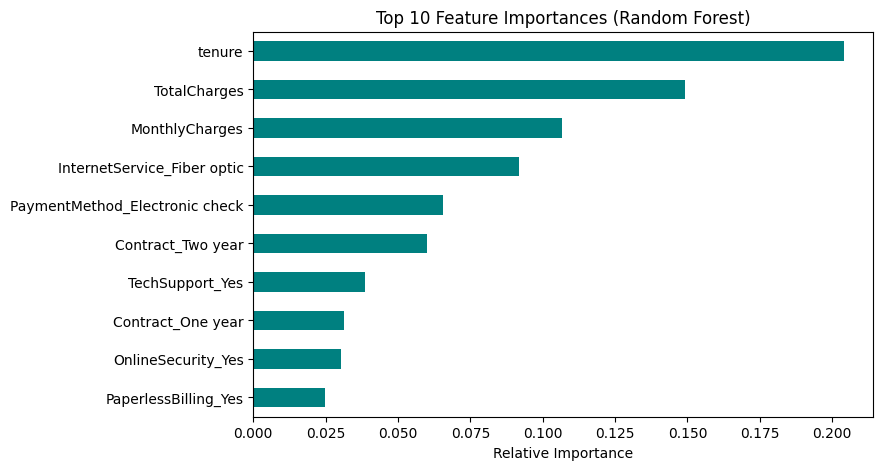

In [63]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

# **Part 3: Model Evaluation**

In [64]:
models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'KNN (K=5)': (y_pred_knn, y_prob_knn),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf)
}

### **Confusion Matrix**

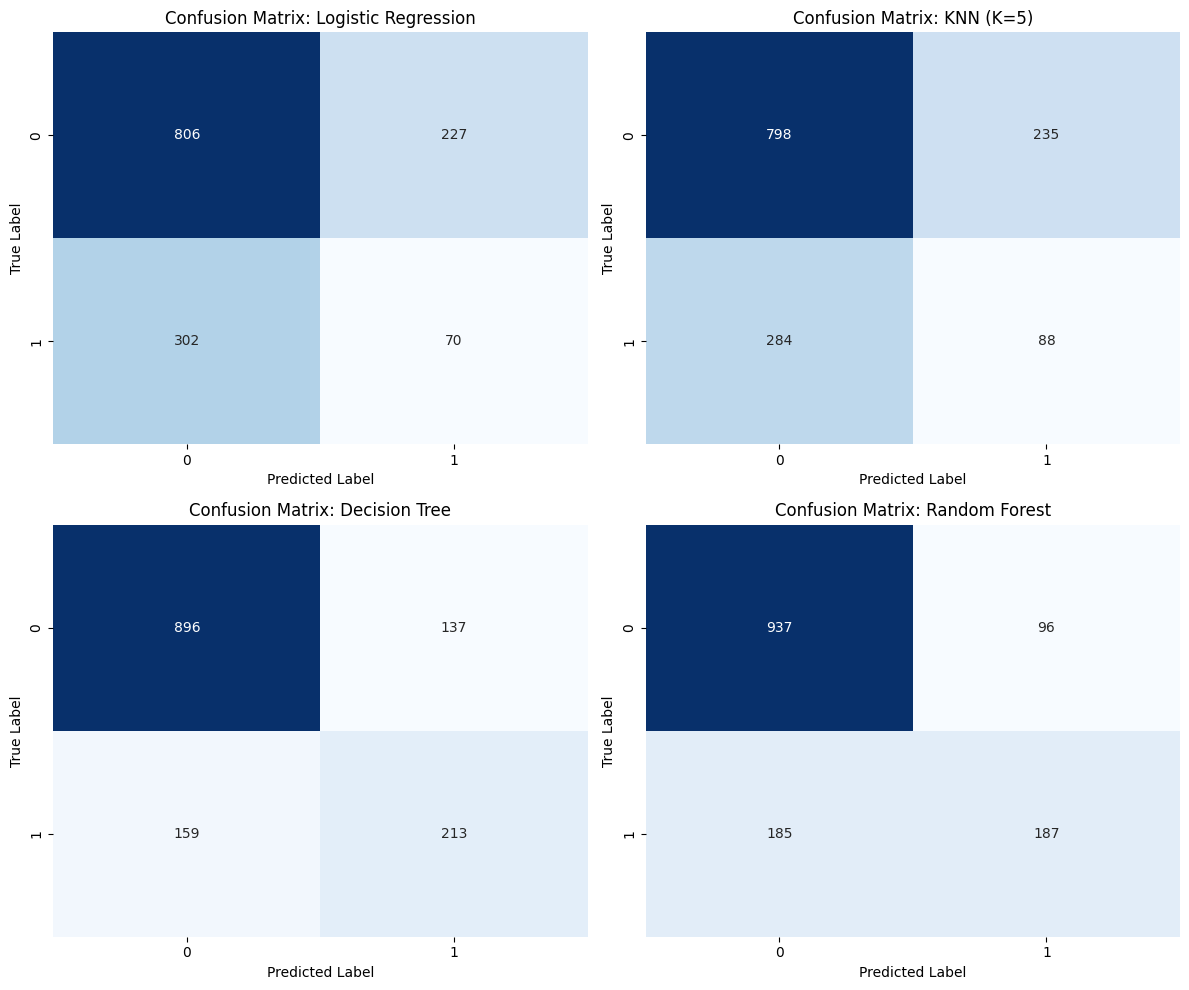

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics_summary = []

for idx, (name, (preds, probs)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    metrics_summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })
plt.tight_layout()
plt.show()

### **ROC Curve Plotting**

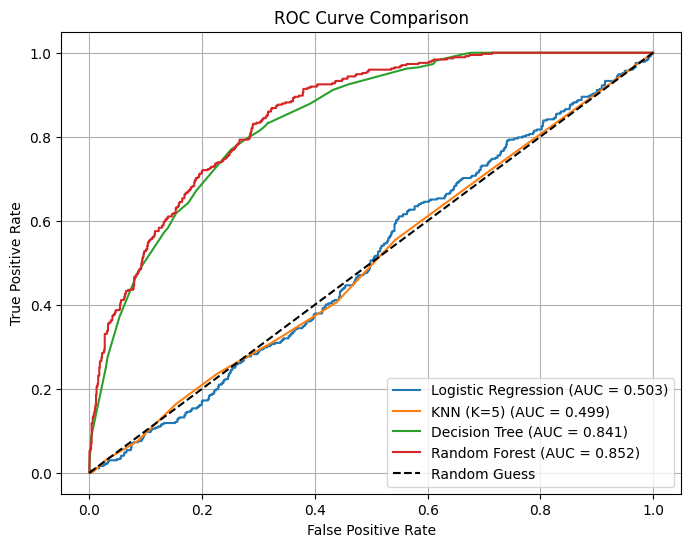

In [73]:
plt.figure(figsize=(8, 6))
for name, (preds, probs) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### **Performance Summary Table**

In [74]:
summary_df = pd.DataFrame(metrics_summary).set_index('Model')
print("Model Performance Summary Table:")
display(summary_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])

Model Performance Summary Table:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.623488,0.235690,0.188172,0.209268,0.503259
KNN (K=5),0.630605,0.272446,0.236559,0.253237,0.499464
Decision Tree,0.789324,0.608571,0.572581,0.590028,0.840715
Random Forest,0.800000,0.660777,0.502688,0.570992,0.852478


Discussion

1.Ans: Based on the results, Random Forest performs best overall.
2.Ans: For a customer churn prediction problem, Recall is generally more important than Precision.

# **Part 4: Insights and Conclusion**

`1.Brief Report`

The objective of this project was to develop a machine learning model to predict customer churn using the Telco Customer Churn dataset.

The dataset was explored and preprocessed by handling missing values, converting categorical variables into numerical representations, and scaling numerical features where necessary. Four classification algorithms were evaluated: Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest.

Among the four models, Random Forest achieved the best overall performance, with an accuracy of 80.0% and ROC-AUC of 0.852.

Decision Tree also performed strongly, achieving an accuracy of approximately 78.9%, recall of 57.3%, and F1 score of 59.0%.

Logistic Regression and KNN performed considerably worse in this experiment, with ROC-AUC scores close to 0.50, indicating weak discriminatory performance.

`2.Key factors that influence customer churn`

Several customer characteristics can potentially influence churn in the Telco dataset.

Important factors commonly associated with churn include:

* Contract type — customers with month-to-month contracts are generally more likely to churn.
* Tenure — newer customers may have a higher risk of leaving.
* Monthly Charges — higher monthly costs may increase churn risk.
* Internet Service — different internet service types can be associated with different churn patterns.
* Online Security and Technical Support — customers without additional support services may have higher churn risk.
* Payment Method — certain payment methods may be associated with higher churn.
* Total Charges — customers with different spending histories may show different churn behavior.

These factors can help telecom companies identify customers who may be at higher risk of leaving.

Important: Since your assignment asks for "key factors," ideally support this section with your Decision Tree/Random Forest feature importance plot rather than claiming these are definitely the top factors from your particular trained model.

`3.I recommend Random Forest for deployment.`

The main reasons are:

It achieved the highest accuracy (80.0%).
It achieved the highest ROC-AUC (0.852).
It achieved the highest precision (68.1%) among the models.
It can capture complex relationships between customer characteristics.
It is less prone to overfitting than a single unrestricted Decision Tree because it combines predictions from multiple trees.

However, its recall was 50.3%, which means it did not identify all actual churners.

Therefore, before deployment, the Random Forest model could be further optimized for higher recall, for example by tuning the classification threshold or using techniques such as class weighting.

`4.Business implications of False Positives and False Negatives`
False Positive

A False Positive occurs when the model predicts that a customer will churn, but the customer actually stays.

The company may unnecessarily:

* provide discounts,
* send retention offers,
* contact the customer,
* or spend marketing resources.

Therefore, false positives can increase the company's retention costs.

False Negative

A False Negative occurs when the model predicts that a customer will stay, but the customer actually churns.

This can be more costly because the company fails to identify a customer who could potentially have been retained.

The company may lose:

* future revenue,
* customer lifetime value,
* the opportunity to take preventive action.

For this reason, reducing False Negatives and improving Recall is particularly important in churn prediction.

`5.Limitations and Potential Improvements`

This project has several limitations.

Limitations
The model was trained using a single dataset, so the results may not generalize to other telecom companies.
The dataset may not contain all factors that influence customer churn.
The models were evaluated using a single train-test split.
The class distribution of churn may affect model performance.
The Logistic Regression and KNN models performed poorly in this experiment.
Hyperparameter tuning was relatively limited.
Potential Improvements

Future work could improve the model by:

Using cross-validation instead of relying on a single train-test split.
Performing more extensive hyperparameter tuning.
Handling class imbalance using class weights or SMOTE where appropriate.
Optimizing the classification threshold to improve Recall.
Performing more detailed feature engineering.
Comparing additional algorithms such as XGBoost or Gradient Boosting.
Using feature importance and explainability techniques such as SHAP.
Testing the final model on new real-world customer data.